# LLM vs. Poets.org Immigration Classification

In [29]:
import pandas as pd
from plotnine import *

df = pd.read_csv('data/df_llm_labels_1.csv', low_memory=False, usecols=['Year', 'poets_org', 'llm'])

# Drop 4 garbled rows where CSV parsing bled into wrong columns
df = df[df['llm'].isin(['TRUE', 'FALSE'])].copy()

# Normalize types
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)
df['llm'] = df['llm'] == 'TRUE'
df['poets_org'] = df['poets_org'].astype(bool)

# Count by year
by_year = df.groupby('Year').agg(
    total=('llm', 'count'),
    llm_immigration=('llm', 'sum'),
    poetsorg_immigration=('poets_org', 'sum')
).astype(int)

by_year['llm_%'] = (by_year['llm_immigration'] / by_year['total'] * 100).round(1)
by_year['poetsorg_%'] = (by_year['poetsorg_immigration'] / by_year['total'] * 100).round(1)

by_year.columns = ['Total Poems', 'LLM: Immigration', 'Poets.org: Immigration', 'LLM %', 'Poets.org %']
by_year

,Total Poems,LLM: Immigration,Poets.org: Immigration,LLM %,Poets.org %
Year,,,,,
2000,94,5,0,5.3,0.0
2001,139,11,0,7.9,0.0
2002,176,15,2,8.5,1.1
2003,196,16,0,8.2,0.0
2004,178,13,1,7.3,0.6
2005,229,17,1,7.4,0.4
2006,189,13,0,6.9,0.0
2007,182,12,0,6.6,0.0
2008,181,13,1,7.2,0.6


In [30]:
by_year = by_year.reset_index()

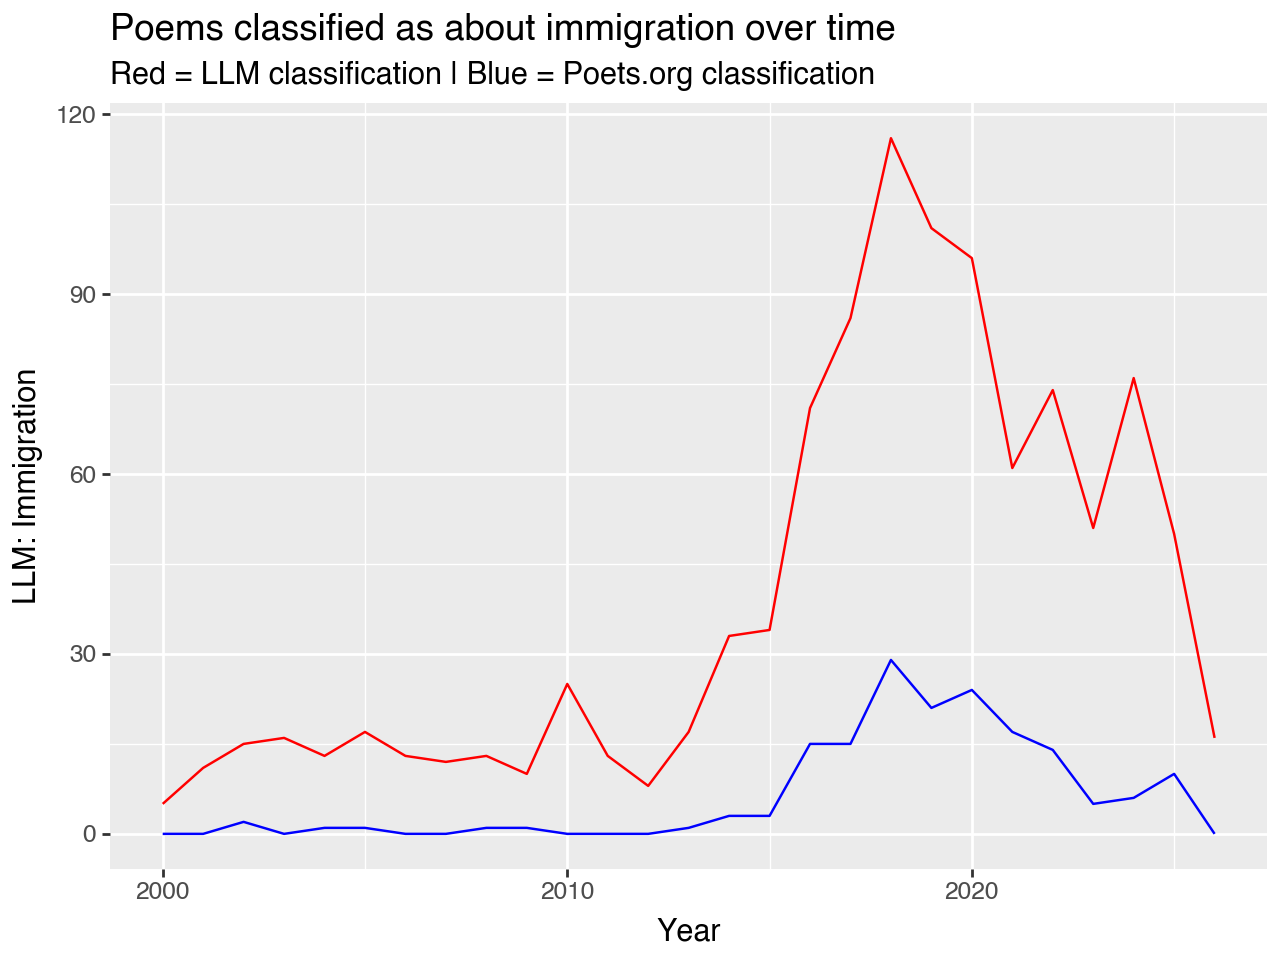

In [31]:
plot_total = (
    ggplot(by_year) +
    geom_line(aes(x='Year', y='LLM: Immigration'), color='Red') +
    geom_line(aes(x='Year', y='Poets.org: Immigration'), color='Blue') +
    labs(title="Poems classified as about immigration over time",
         subtitle="Red = LLM classification | Blue = Poets.org classification")
)
plot_total

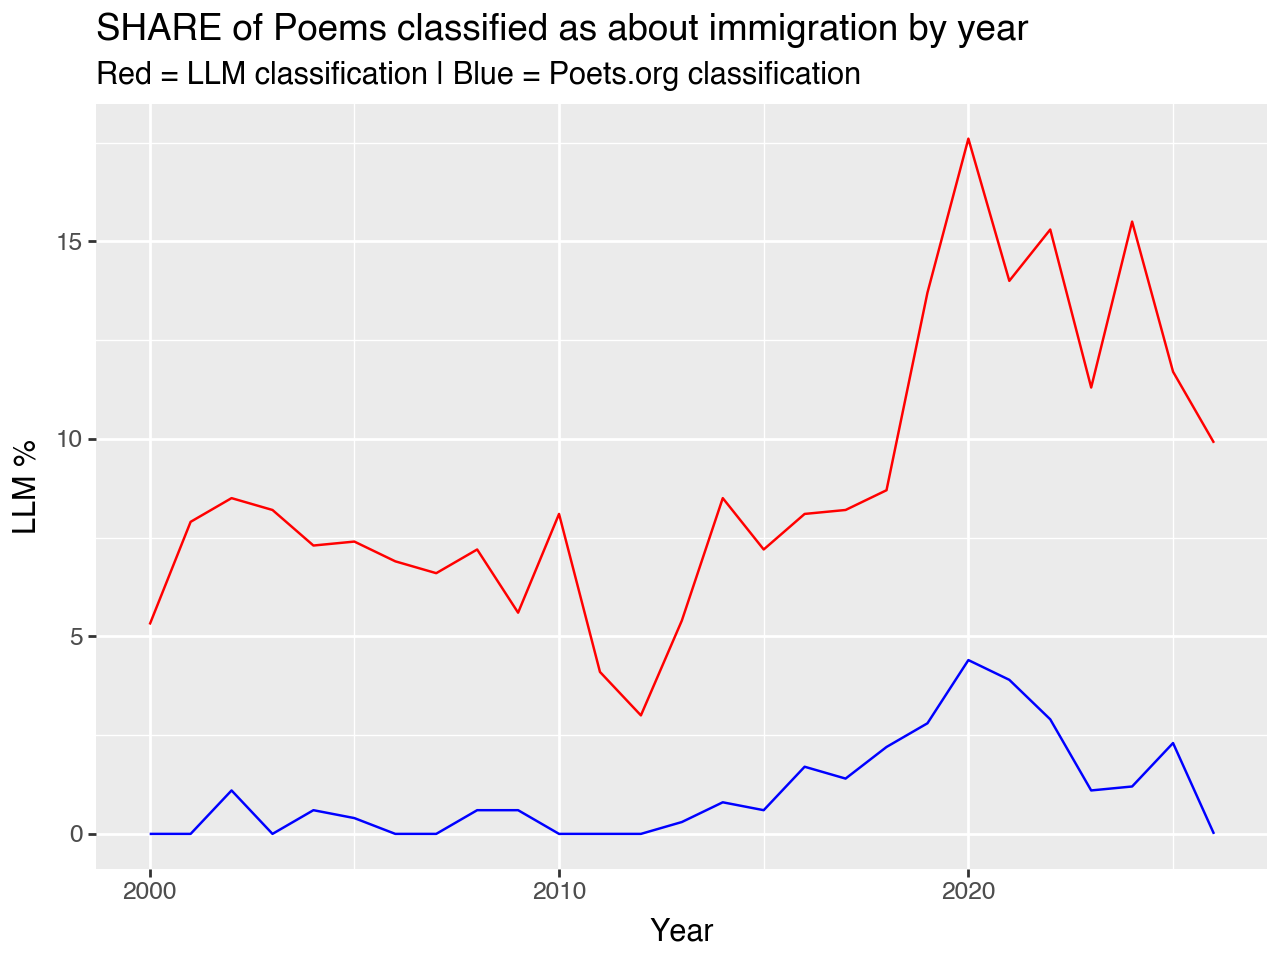

In [32]:
plot_share = (
    ggplot(by_year) +
    geom_line(aes(x='Year', y='LLM %'), color='Red') +
    geom_line(aes(x='Year', y='Poets.org %'), color='Blue') +
    labs(title="SHARE of Poems classified as about immigration by year",
         subtitle="Red = LLM classification | Blue = Poets.org classification")
)
plot_share

In [33]:
plot_total.save(filename="classification_count.png", width=6, height=4, units="in", dpi=300)
plot_share.save(filename="classification_share.png", width=6, height=4, units="in", dpi=300)


/Users/hgorledeenn/.pyenv/versions/3.13.9/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6 x 4 in image.
/Users/hgorledeenn/.pyenv/versions/3.13.9/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: classification_count.png
/Users/hgorledeenn/.pyenv/versions/3.13.9/lib/python3.13/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6 x 4 in image.
/Users/hgorledeenn/.pyenv/versions/3.13.9/lib/python3.13/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: classification_share.png
